# Laboratorio 5 — Clasificación de tweets usando minería de texto

**Universidad del Valle de Guatemala** · Facultad de Ingeniería · Departamento de Ciencias de la Computación
**CC3084 — Data Science** · Semestre II – 2026

**Entrega:** Avance (descripción de los datos, preprocesamiento, unigramas, bigramas y modelo preliminar de clasificación)

**Dataset:** [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/c/nlp-getting-started) (Kaggle)

**Objetivo del laboratorio:** construir un clasificador que determine si un tweet se refiere a un desastre real (`target = 1`) o no (`target = 0`).


## 1. Carga de librerías y datos

Se utilizan las siguientes librerías de Python:

- **pandas / numpy**: manipulación de datos.
- **matplotlib / seaborn**: visualización.
- **nltk**: stopwords y tokenización.
- **wordcloud**: nube de palabras.
- **scikit-learn**: vectorización (TF-IDF, `CountVectorizer` para n-gramas) y modelos de clasificación.
- **re / string**: limpieza de texto con expresiones regulares.


In [1]:
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42


In [2]:
df = pd.read_csv("data/train.csv")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 7613 filas x 5 columnas


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 2. Descripción general de los datos

El dataset contiene `id`, `keyword`, `location`, `text` y `target`. Revisamos tipos de datos, valores nulos y el balance de la variable objetivo antes de cualquier preprocesamiento.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [4]:
missing = df.isna().sum().to_frame("valores_nulos")
missing["% del total"] = (missing["valores_nulos"] / len(df) * 100).round(2)
missing


,valores_nulos,% del total
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


**Observaciones sobre valores nulos:**

- `keyword` tiene muy pocos nulos (~0.8%): se puede imputar con una categoría `"sin_keyword"` o simplemente ignorarse en el texto libre.
- `location` tiene una proporción alta de nulos (~33%) y además es texto libre no normalizado (ciudades, países, ubicaciones inventadas como "Earth" o "everywhere"), por lo que **no se usará como predictor directo** en esta etapa; su valor real estaría en un procesamiento de geolocalización que excede el alcance de este laboratorio.
- `text` y `target` no tienen nulos: son las columnas centrales del análisis.


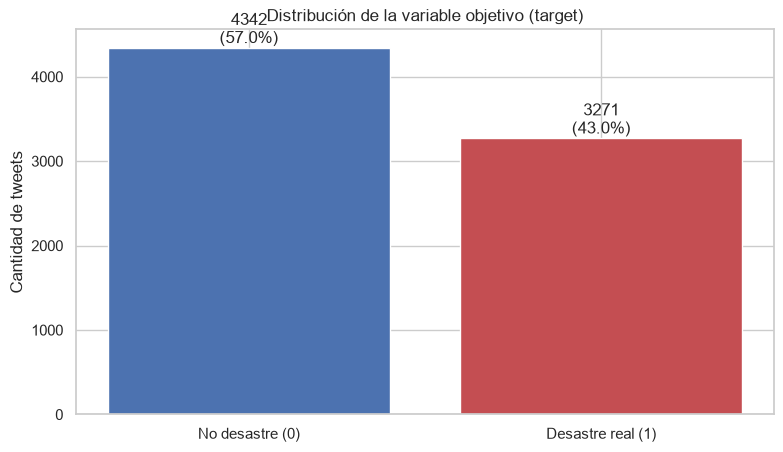

target
0    4342
1    3271
Name: count, dtype: int64


In [5]:
target_counts = df["target"].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(1)

fig, ax = plt.subplots()
bars = ax.bar(["No desastre (0)", "Desastre real (1)"], target_counts.values,
              color=["#4C72B0", "#C44E52"])
for bar, pct in zip(bars, target_pct.values):
    ax.annotate(f"{bar.get_height()}\n({pct}%)", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
ax.set_ylabel("Cantidad de tweets")
ax.set_title("Distribución de la variable objetivo (target)")
plt.show()

print(target_counts)


**Balance de clases:** el dataset está moderadamente desbalanceado (~57% no-desastre vs. ~43% desastre real), pero no de forma extrema. Se tomará en cuenta al evaluar los modelos (usar métricas como *precision*, *recall* y *F1*, no solo *accuracy*, y aplicar `stratify` en el split de entrenamiento/prueba).


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18624\1112829799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keyword_counts.values, y=keyword_counts.index, ax=ax, palette="viridis")


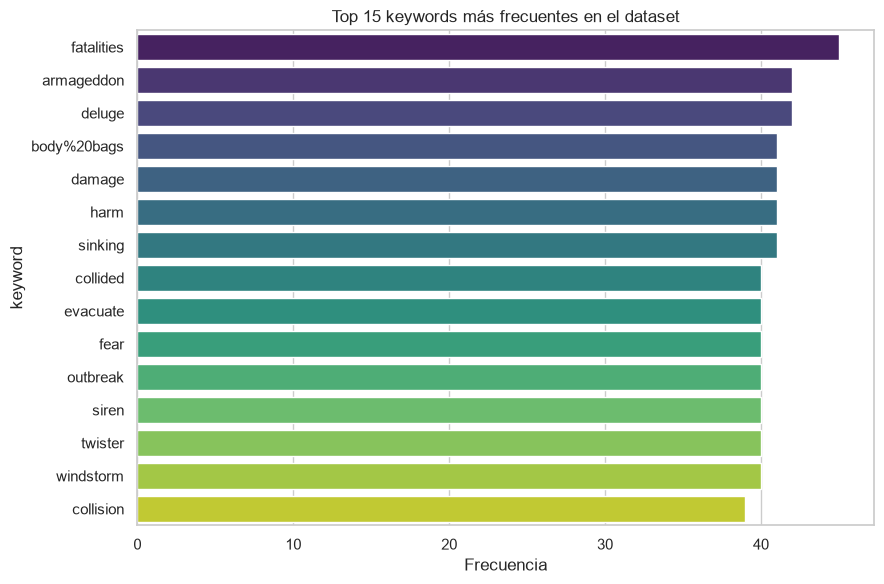

In [6]:
keyword_counts = df["keyword"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=keyword_counts.values, y=keyword_counts.index, ax=ax, palette="viridis")
ax.set_xlabel("Frecuencia")
ax.set_title("Top 15 keywords más frecuentes en el dataset")
plt.tight_layout()
plt.show()


In [7]:
disaster_rate_by_keyword = (
    df.dropna(subset=["keyword"])
      .groupby("keyword")["target"]
      .agg(["mean", "count"])
      .rename(columns={"mean": "tasa_desastre", "count": "n_tweets"})
)

print("Keywords MÁS asociadas a desastre real:")
print(disaster_rate_by_keyword[disaster_rate_by_keyword["n_tweets"] >= 10].sort_values("tasa_desastre", ascending=False).head(10))

print("\nKeywords MENOS asociadas a desastre real:")
print(disaster_rate_by_keyword[disaster_rate_by_keyword["n_tweets"] >= 10].sort_values("tasa_desastre", ascending=True).head(10))


Keywords MÁS asociadas a desastre real:
                   tasa_desastre  n_tweets
keyword                                   
debris                  1.000000        37
derailment              1.000000        39
wreckage                1.000000        39
outbreak                0.975000        40
oil%20spill             0.973684        38
typhoon                 0.973684        38
suicide%20bombing       0.969697        33
suicide%20bomber        0.967742        31
bombing                 0.931034        29
suicide%20bomb          0.914286        35

Keywords MENOS asociadas a desastre real:
             tasa_desastre  n_tweets
keyword                             
aftershock        0.000000        34
body%20bags       0.024390        41
ruin              0.027027        37
blazing           0.029412        34
body%20bag        0.030303        33
electrocute       0.031250        32
screaming         0.055556        36
traumatised       0.057143        35
panicking         0.060606     

**Observación:** existen keywords casi perfectamente asociadas a una clase (p. ej. `debris`, `wreckage`, `derailment` casi siempre son desastre real; `aftershock` casi nunca lo es a pesar del nombre). Esto sugiere que `keyword`, aunque no es el foco del análisis de texto libre, **podría usarse como variable auxiliar** en el modelo final.
